## Connect duckdb in python

In [ ]:
import duckdb

with duckdb.connect("database/jokes.duckdb") as conn:
    conn.sql("DROP TABLE IF EXISTS jokes;")

    conn.sql("""--sql
        CREATE TABLE IF NOT EXISTS jokes (
             id INT,
             joke STRING
        );
    """)

    conn.sql("""--sql
        INSERT INTO jokes VALUES
             (1, 'Why do programmers hate sunlight, because they attract bugs'),
             (2, 'Why do java programmers need glasses, because they cannot C#'); 
    """)

    desc = conn.sql("DESC;").df()


In [3]:
desc

,database,schema,name,column_names,column_types,temporary
0,jokes,main,jokes,"[id, joke]","[INTEGER, VARCHAR]",False


In [24]:
with duckdb.connect("database/jokes.duckdb") as conn: 
    jokes = conn.sql("FROM jokes;").df()

# outside -> db connection is closed
# but have saved dataframe to jokes variable
jokes

,id,joke
0,1,"Why do programmers hate sunlight, because they..."
1,2,"Why do java programmers need glasses, because ..."


In [9]:
jokes["joke"]

0    Why do programmers hate sunlight, because they...
1    Why do java programmers need glasses, because ...
Name: joke, dtype: object

## Ingest a csv file into duckdb 

- we can open a csv file without a database connection

In [38]:
# same as pd.read_csv()
finance = duckdb.sql("FROM 'data/financial_data.csv'").df()
finance.head(2)

,transaction_id,date,company,transaction_type,category,amount,currency,account_number,description,status,payment_method,tax_amount,net_amount
0,TXN1000,2024-01-15,UnitedHealth Group,Investment,Marketing,498789.60,JPY,ACC90616,Q1 revenue for r&d,Completed,Check,15640.11,483149.49
1,TXN1001,2024-12-22,Broadcom Inc,Expense,Administrative,407890.44,GBP,ACC72475,Q4 capital gain for it,Completed,Wire Transfer,25883.85,382006.59


In [36]:
finance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    50 non-null     object        
 1   date              50 non-null     datetime64[us]
 2   company           50 non-null     object        
 3   transaction_type  50 non-null     object        
 4   category          50 non-null     object        
 5   amount            50 non-null     float64       
 6   currency          50 non-null     object        
 7   account_number    50 non-null     object        
 8   description       50 non-null     object        
 9   status            50 non-null     object        
 10  payment_method    50 non-null     object        
 11  tax_amount        50 non-null     float64       
 12  net_amount        50 non-null     float64       
dtypes: datetime64[us](1), float64(3), object(9)
memory usage: 5.2+ KB


In [39]:
finance["category"].value_counts()

category
Operations        8
Legal             6
Administrative    5
Distribution      5
HR                5
IT                5
Sales             5
Marketing         4
R&D               4
Manufacturing     3
Name: count, dtype: int64

## SQL query directly on a dataframe 

In [ ]:
df_category_amount = duckdb.sql("""--sql
    SELECT
        category,
        SUM(amount) AS total_amount
    FROM finance
    GROUP BY category
    ORDER BY total_amount DESC
    """).df()

df_category_amount

,category,total_amount
0,Operations,2516205.96
1,Administrative,1524607.15
2,Marketing,1434237.33
3,IT,1272719.86
4,Distribution,1266188.51
5,R&D,1223866.29
6,Manufacturing,1140503.86
7,Sales,1086062.70
8,Legal,923504.37
9,HR,301675.46


<Axes: title={'center': 'Total amount per category'}, xlabel='category', ylabel='total amount'>

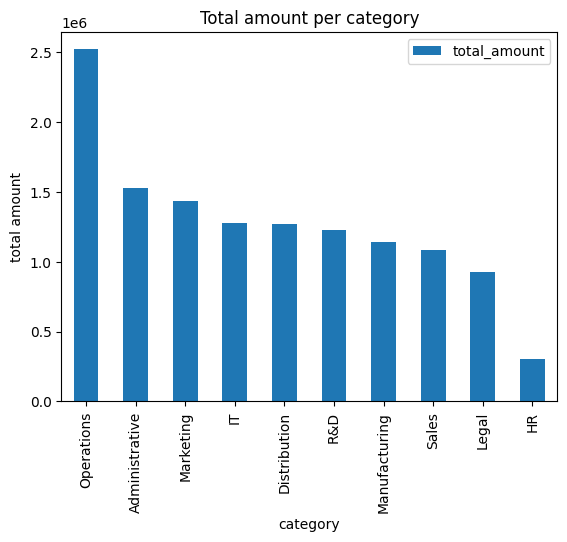

In [51]:
df_category_amount.plot(
    x="category",
    y="total_amount",
    kind="bar",
    title="Total amount per category",
    xlabel="category",
    ylabel="total amount",
)